## Question: "Over what redshift range can I observe line X with grating Y?"

### Some NIRSpec Docs
- [Dispersers & Filters](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-dispersers-and-filters#gsc.tab=0)
- [Position Angles / Detector Gaps](https://jwst-docs.stsci.edu/jwst-near-infrared-spectrograph/nirspec-instrumentation/nirspec-detectors#gsc.tab=0)

In [ ]:
# Pandeia reference data (only needed to locate the config file)
import os
os.environ["pandeia_refdata"] = "../../data/pandeia_data-2026.7-jwst"

import json
import numpy as np
import matplotlib.pyplot as plt

# Emission line to observe (rest-frame)
line_name = 'H alpha'
line_rest_um = 0.6563

# Fixed-slit aperture (the detector gap depends on this!!!)
aperture = 's200a1'

# Optional: a specific redshift to highlight on the plot (set to None to skip)
target_redshift = 5.0

# Filters paired with the single-filter gratings (for display)
FILTER_PAIRS = {'g235h': 'f170lp', 
                 'g235m': 'f170lp',
                 'g395h': 'f290lp', 
                 'g395m': 'f290lp', 
                 'prism': 'clear'}

In [ ]:
def read_coverage(aperture):
    """Read (grating, filter, wave_min, wave_max, gap_start, gap_end) for every
    grating/filter of a NIRSpec fixed-slit aperture, from Pandeia's config."""
    
    path = f"{os.environ['pandeia_refdata']}/jwst/nirspec/config.json"
    gap = json.load(open(path))['slit_config'][aperture]['gap']['default']
    
    rows = []
    for disp, node in gap.items():
        # some gratings hold values directly; others nest by filter
        items = [(None, node)] if 'wave_min' in node else list(node.items())
        for filt, v in items:
            filt = filt or FILTER_PAIRS.get(disp, '')
            rows.append((disp, filt, v['wave_min'], v['wave_max'],
                         v['gap_start'], v['gap_end']))
    return rows


def redshift_coverage(line_rest_um, aperture):
    """For each grating/filter, the redshift range where the observed line is
    covered, plus the 'blind' redshift band from the detector gap (if any)."""
    
    out = []
    for disp, filt, wmin, wmax, gs, ge in read_coverage(aperture):
        z_lo = max(0.0, wmin / line_rest_um - 1.0)
        z_hi = wmax / line_rest_um - 1.0
        
        if z_hi < 0:
            continue  # line is redward of this grating even at z=0
        
        # If the grating has a detector gap, compute the redshift range where the line
        # falls in the gap. If the gap is outside the grating coverage, ignore it.
        gap_z = None
        if gs is not None:
            
            # Compute the redshift range where the line falls in the gap
            gz_lo = gs / line_rest_um - 1.0
            gz_hi = ge / line_rest_um - 1.0
            
            # Check if the gap overlaps the grating coverage. If so, compute the overlap.
            if gz_hi > z_lo and gz_lo < z_hi: # gap overlaps coverage
                gap_z = (max(z_lo, gz_lo), min(z_hi, gz_hi))

        # Store the results for this grating/filter
        out.append(dict(disp=disp, filt=filt, wmin=wmin, wmax=wmax,
                        z_lo=z_lo, z_hi=z_hi, gap_z=gap_z))
        
    return sorted(out, key=lambda r: r['z_lo'])

H alpha (rest 0.6563 um) observable redshift ranges [for aperture s200a1]

grating/filter   coverage (um)    observable z     blind z (gap)   
------------------------------------------------------------------
prism/clear      0.60-5.30        0.00-7.08        -               
g140m/f070lp     0.70-1.27        0.07-0.94        -               
g140h/f070lp     0.81-1.27        0.24-0.94        -               
g140h/f100lp     0.97-1.82        0.48-1.77        0.98-1.04       
g140m/f100lp     0.97-1.84        0.48-1.80        -               
g235h/f170lp     1.66-3.05        1.53-3.65        2.33-2.42       
g235m/f170lp     1.66-3.07        1.53-3.68        -               
g395h/f290lp     2.87-5.14        3.37-6.83        4.61-4.77       
g395m/f290lp     2.87-5.09        3.37-6.76        -               

At z=5.0:
  prism/clear: line at 3.938 um -> observable
  g395h/f290lp: line at 3.938 um -> observable
  g395m/f290lp: line at 3.938 um -> observable


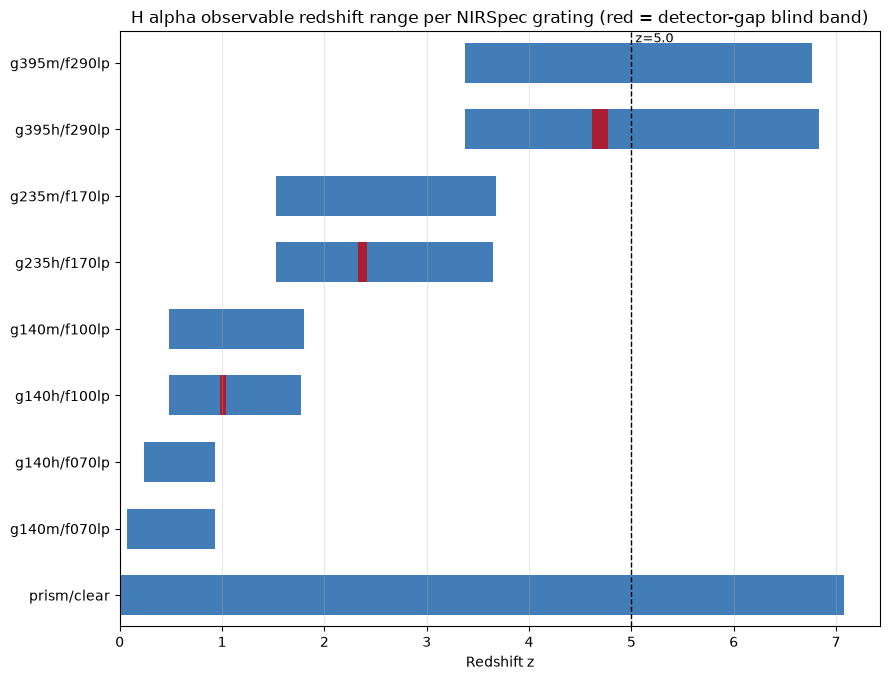

In [12]:
rows = redshift_coverage(line_rest_um, aperture)

# Planning table
print(f"{line_name} (rest {line_rest_um} um) observable redshift ranges [for aperture {aperture}]\n")
print(f"{'grating/filter':16} {'coverage (um)':16} {'observable z':16} {'blind z (gap)':16}")
print("-" * 66)

# Print the planning table
for r in rows:
    cov = f"{r['wmin']:.2f}-{r['wmax']:.2f}"
    zr = f"{r['z_lo']:.2f}-{r['z_hi']:.2f}"
    gz = f"{r['gap_z'][0]:.2f}-{r['gap_z'][1]:.2f}" if r['gap_z'] else "-"
    print(f"{r['disp']+'/'+r['filt']:16} {cov:16} {zr:16} {gz:16}")

# Plot: redshift coverage bars
fig, ax = plt.subplots(figsize=(9, 0.6 * len(rows) + 1.5))

# Plot the coverage bars for each grating/filter
for i, r in enumerate(rows):
    ax.barh(i, r['z_hi'] - r['z_lo'], left=r['z_lo'], height=0.6,
            color='#2166ac', alpha=0.85)
    
    # If the grating/filter has a detector gap, plot the blind redshift range in red
    if r['gap_z']:
        ax.barh(i, r['gap_z'][1] - r['gap_z'][0], left=r['gap_z'][0], height=0.6,
                color='#b2182b', alpha=0.95)

# Format the plot
ax.set_yticks(range(len(rows)))
ax.set_yticklabels([f"{r['disp']}/{r['filt']}" for r in rows])
ax.set_xlabel('Redshift z')
ax.set_title(f"{line_name} observable redshift range per NIRSpec grating "
             f"(red = detector-gap blind band)")

# Highlight a specific redshift if requested
if target_redshift is not None:
    ax.axvline(target_redshift, color='k', ls='--', lw=1)
    ax.text(target_redshift, len(rows) - 0.55, f" z={target_redshift}", fontsize=9, va='top')
    
    # report which gratings cover the target z
    print(f"\nAt z={target_redshift}:")
    for r in rows:
        
        # Check if the target redshift is within the observable range of this grating/filter
        if r['z_lo'] <= target_redshift <= r['z_hi']:
            in_gap = r['gap_z'] and r['gap_z'][0] <= target_redshift <= r['gap_z'][1]
            obs = f"{line_rest_um * (1 + target_redshift):.3f} um"
            print(f"  {r['disp']}/{r['filt']}: line at {obs} -> "
                  f"{'IN DETECTOR GAP (not observable)' if in_gap else 'observable'}")

# Format the plot
ax.grid(axis='x', alpha=0.3)
ax.margins(y=0.02)
plt.tight_layout()
plt.show()